In [334]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [335]:
df = pd.read_csv("../loan_analysis/loan_approval_dataset.csv")

In [336]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [337]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [338]:
df.shape

(4269, 13)

In [339]:
df.dtypes

loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object

In [340]:
# some stats about data 
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


 Check null valuess 


In [341]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

check duplicates

In [342]:
df.duplicated().sum()

np.int64(0)

In [343]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [344]:
# remove unnecessary spaces from columns name and values
df.columns = df.columns.str.strip()
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [345]:
df['education'] = df['education'].str.strip()
df['self_employed'] =df['self_employed'].str.strip()
df['loan_status'] =df['loan_status'].str.strip()

outliers detetction

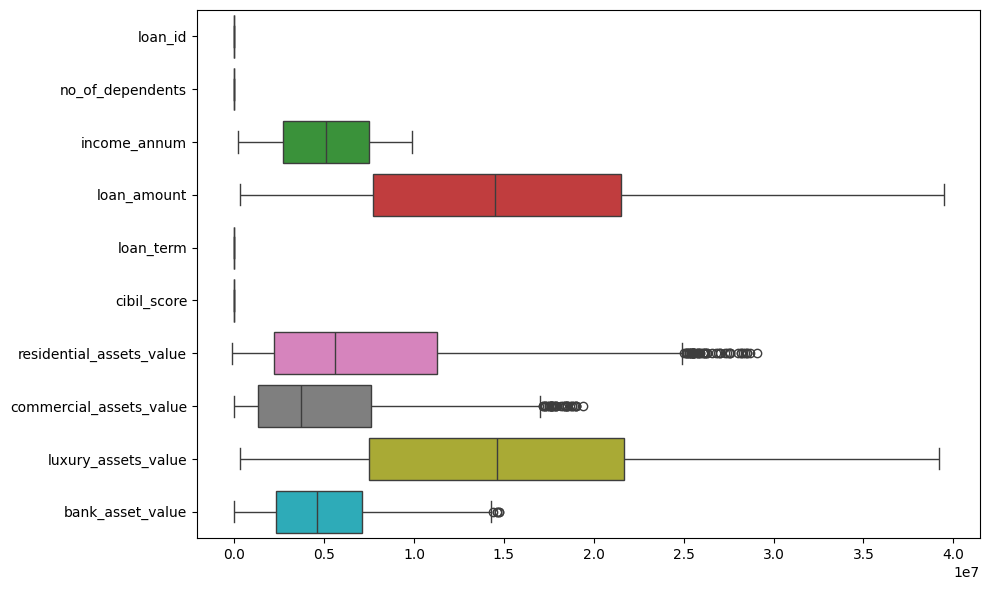

In [346]:
# check for outliers in visualization with subplots
plt.figure(figsize=(10,6))
sns.boxplot(data=df, orient= 'h')
plt.tight_layout()
plt.show()

outliers detected in residentoal_assets_value,commercial_assets_value and  bank_asset_value

In [347]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers


In [348]:
for column in df.select_dtypes(include=[np.number]).columns:
    iqr_outliers = detect_outliers_iqr(df, column)
    
print(f"\nColumn: {column}")
print(f"IQR method outliers: {len(iqr_outliers)}")


Column: bank_asset_value
IQR method outliers: 5


detect outliers using z score 


In [349]:
#detect outliers using z score 
from scipy import stats
def detect_outliers_zscore(df, column, threshold=3):
    z_scores = np.abs(stats.zscore(df[column]))
    outliers = df[z_scores > threshold]
    return outliers


In [350]:
for column in df.select_dtypes(include=[np.number]).columns:
    z_score_outliers = detect_outliers_zscore(df, column)
    print(f"\nColumn: {column}")
    print(f"Z-score method outliers: {len(z_score_outliers)}")


Column: loan_id
Z-score method outliers: 0

Column: no_of_dependents
Z-score method outliers: 0

Column: income_annum
Z-score method outliers: 0

Column: loan_amount
Z-score method outliers: 0

Column: loan_term
Z-score method outliers: 0

Column: cibil_score
Z-score method outliers: 0

Column: residential_assets_value
Z-score method outliers: 16

Column: commercial_assets_value
Z-score method outliers: 17

Column: luxury_assets_value
Z-score method outliers: 0

Column: bank_asset_value
Z-score method outliers: 0


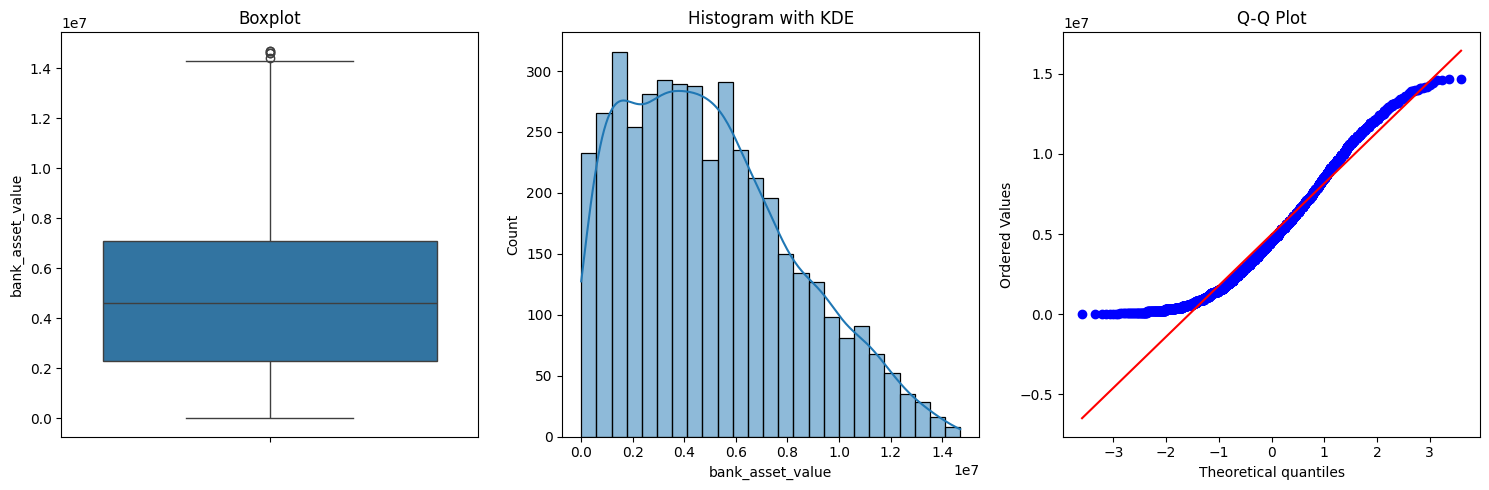

In [351]:
# Visualization fot bank_asset_value
plt.figure(figsize=(15, 5))
    
plt.subplot(1, 3, 1)
sns.boxplot(df['bank_asset_value'])
plt.title('Boxplot')
    
plt.subplot(1, 3, 2)
sns.histplot(df['bank_asset_value'], kde=True)
plt.title('Histogram with KDE')
    
plt.subplot(1, 3, 3)
stats.probplot(df['bank_asset_value'], dist="norm", plot=plt)
plt.title('Q-Q Plot')
    
plt.tight_layout()
plt.show()

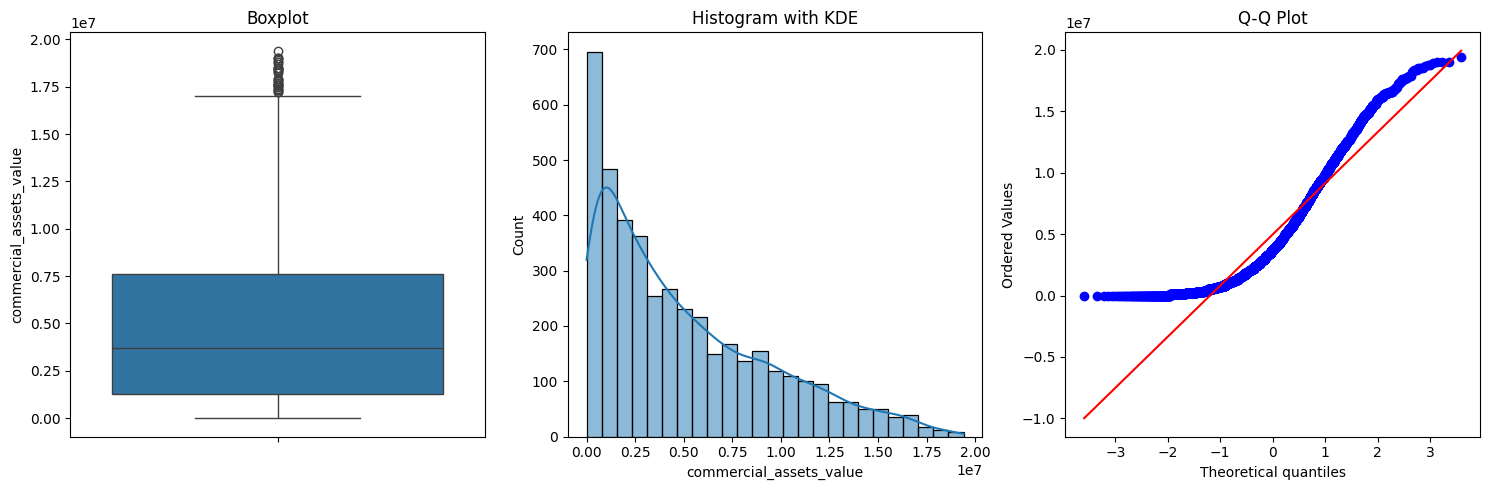

In [352]:
# Visualization fot commercial_assets_value
plt.figure(figsize=(15, 5))
    
plt.subplot(1, 3, 1)
sns.boxplot(df['commercial_assets_value'])
plt.title('Boxplot')
    
plt.subplot(1, 3, 2)
sns.histplot(df['commercial_assets_value'], kde=True)
plt.title('Histogram with KDE')
    
plt.subplot(1, 3, 3)
stats.probplot(df['commercial_assets_value'], dist="norm", plot=plt)
plt.title('Q-Q Plot')
    
plt.tight_layout()
plt.show()

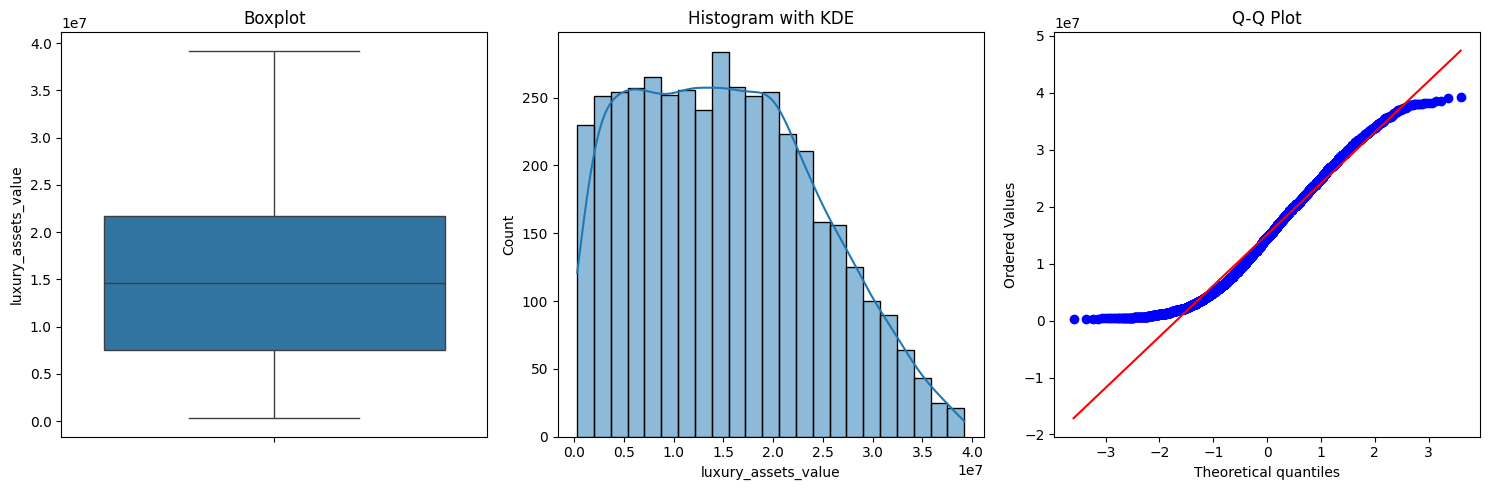

In [353]:
# Visualization fot luxury_assets_value
plt.figure(figsize=(15, 5))
    
plt.subplot(1, 3, 1)
sns.boxplot(df['luxury_assets_value'])
plt.title('Boxplot')
    
plt.subplot(1, 3, 2)
sns.histplot(df['luxury_assets_value'], kde=True)
plt.title('Histogram with KDE')
    
plt.subplot(1, 3, 3)
stats.probplot(df['luxury_assets_value'], dist="norm", plot=plt)
plt.title('Q-Q Plot')
    
plt.tight_layout()
plt.show()

Boxplots showing potential outliers as individual points.
Histograms showing the overall distribution of the data. that is Skewed and not Normal

treating Outliers
Caping with Outliers , In the dataset loan Approval , extreme values in commercial , luxury and bank asset values are possible since there can be people having lots of money in Bank and having more worth properties , as it can be crucial values for our analysis and modelling we will cape with it

In [354]:
def cap_outliers(df, column, method='IQR'):
    if method == 'IQR':
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
    elif method == 'zscore':
        mean = df[column].mean()
        std = df[column].std()
        lower_bound = mean - 3 * std
        upper_bound = mean + 3 * std
    
    df[column] = np.clip(df[column], lower_bound, upper_bound)
    return df

# Apply to all numerical columns
for column in df.select_dtypes(include=[np.number]).columns:
    df = cap_outliers(df, column, method='IQR') 

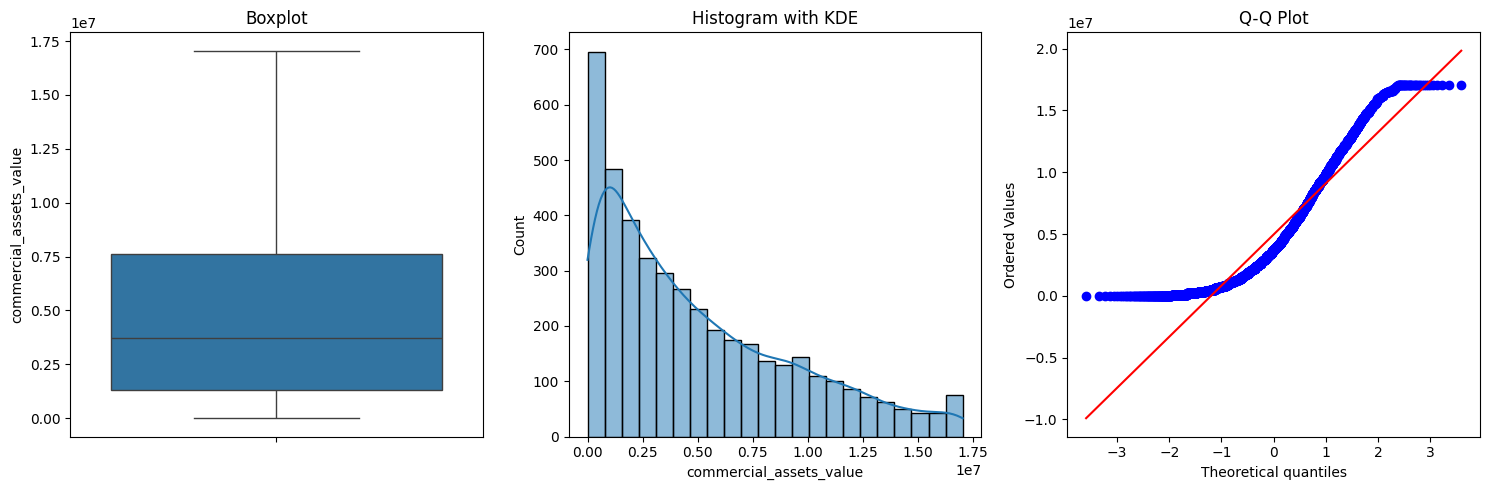

In [355]:
# Visualization fot commercial_assets_value
plt.figure(figsize=(15, 5))
    
plt.subplot(1, 3, 1)
sns.boxplot(df['commercial_assets_value'])
plt.title('Boxplot')
    
plt.subplot(1, 3, 2)
sns.histplot(df['commercial_assets_value'], kde=True)
plt.title('Histogram with KDE')
    
plt.subplot(1, 3, 3)
stats.probplot(df['commercial_assets_value'], dist="norm", plot=plt)
plt.title('Q-Q Plot')
    
plt.tight_layout()
plt.show()

**EDA**


In [356]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17050000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [357]:
# identfiyng uniqe values 
columns_to_count = ['no_of_dependents', 'education', 'self_employed',
        'loan_term', 'loan_status']
for column in columns_to_count:
    print(df[col])

0       Approved
1       Rejected
2       Rejected
3       Rejected
4       Rejected
          ...   
4264    Rejected
4265    Approved
4266    Rejected
4267    Approved
4268    Approved
Name: loan_status, Length: 4269, dtype: object
0       Approved
1       Rejected
2       Rejected
3       Rejected
4       Rejected
          ...   
4264    Rejected
4265    Approved
4266    Rejected
4267    Approved
4268    Approved
Name: loan_status, Length: 4269, dtype: object
0       Approved
1       Rejected
2       Rejected
3       Rejected
4       Rejected
          ...   
4264    Rejected
4265    Approved
4266    Rejected
4267    Approved
4268    Approved
Name: loan_status, Length: 4269, dtype: object
0       Approved
1       Rejected
2       Rejected
3       Rejected
4       Rejected
          ...   
4264    Rejected
4265    Approved
4266    Rejected
4267    Approved
4268    Approved
Name: loan_status, Length: 4269, dtype: object
0       Approved
1       Rejected
2       Rejected
3       Rejec

distribution of featuers

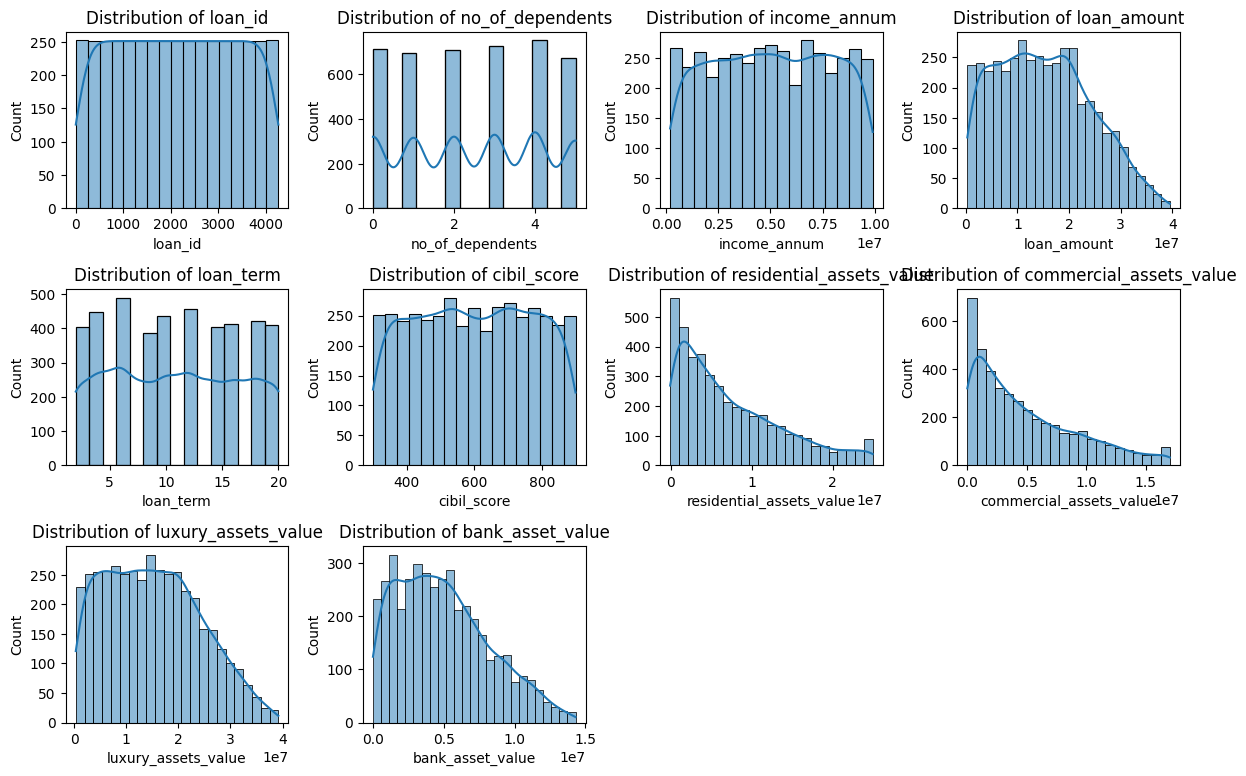

In [358]:
num_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12,10))

for i, column in enumerate(num_cols,1):
    plt.subplot(4,4,i)
    sns.histplot(data=df,x=column ,kde=True)
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

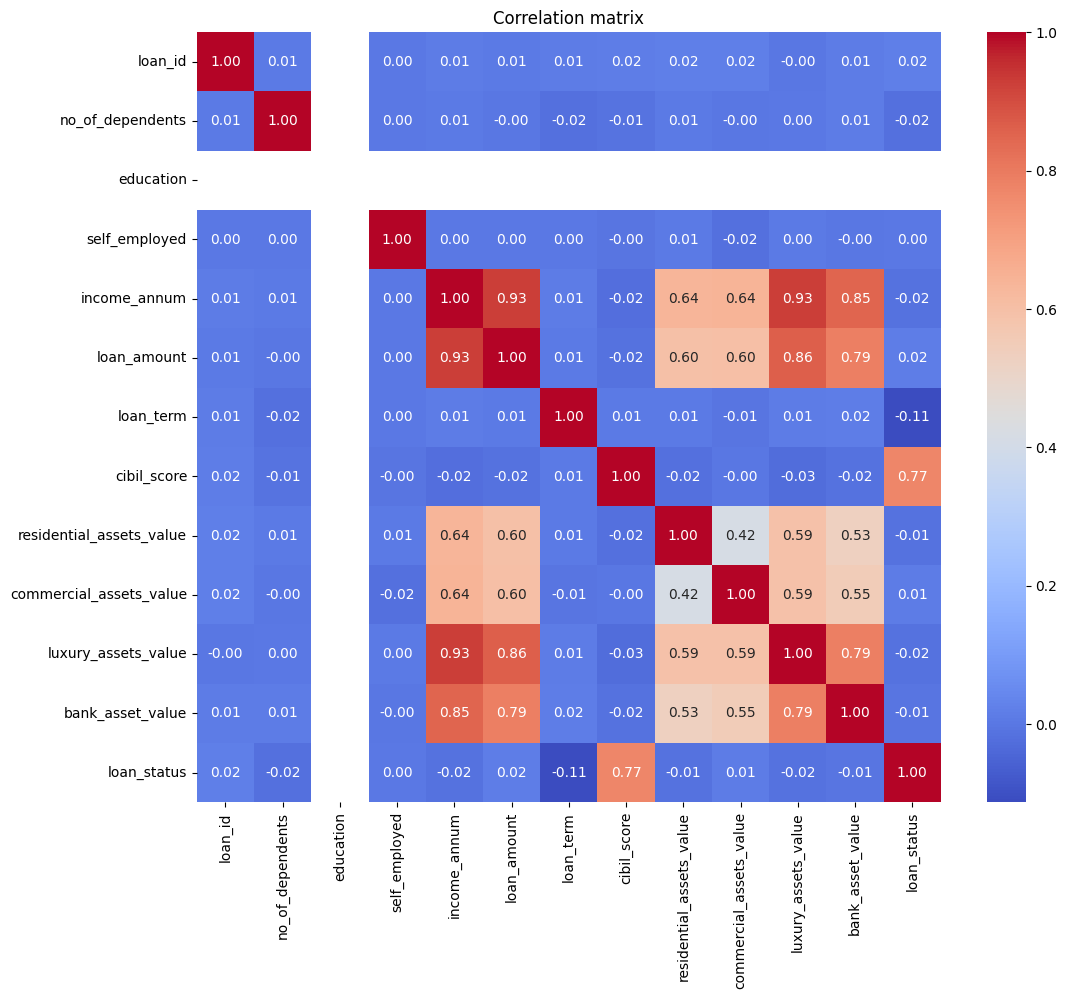

In [359]:
# check correlation 
df_corr = df.copy()
binary_cols = ["education", "self_employed", "loan_status"]
for col in binary_cols:
    df_corr[col] = df_corr[col].map({'Yes': 1, 'No': 0} if col != 'loan_status' else {'Approved': 1, 'Rejected': 0})

plt.figure(figsize=(12,10))

corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()


Visualizing NUMERIC FEATURES RELATIONSHIP(CORRELATION)

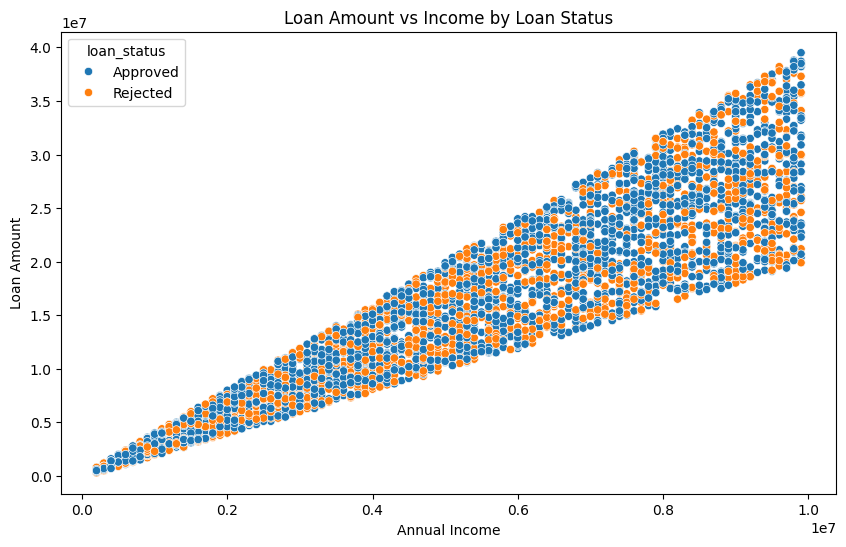

In [360]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='income_annum', y='loan_amount', hue='loan_status')
plt.xlabel('Annual Income')
plt.ylabel('Loan Amount')
plt.title('Loan Amount vs Income by Loan Status')
plt.show()


Applicants with high income tends to take apply for high loan amounts

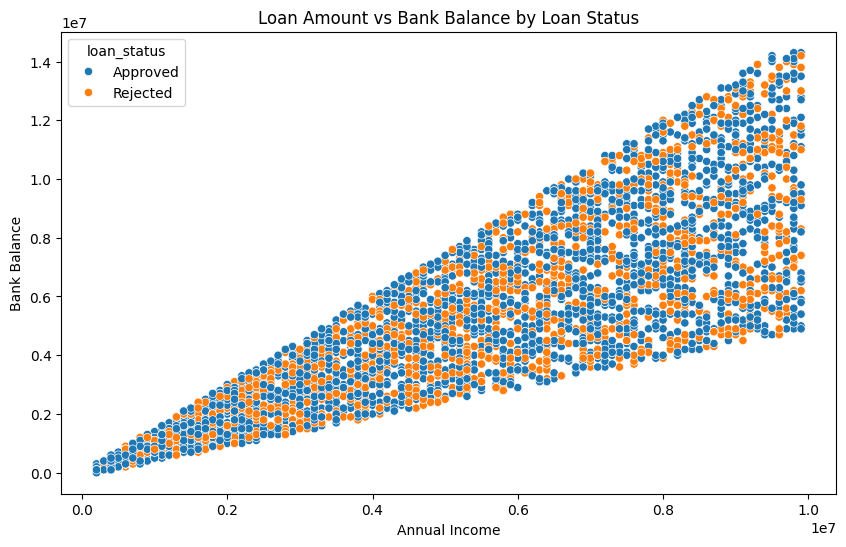

In [361]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='income_annum', y='bank_asset_value', hue='loan_status')
plt.xlabel('Annual Income')
plt.ylabel('Bank Balance')
plt.title('Loan Amount vs Bank Balance by Loan Status')
plt.show()

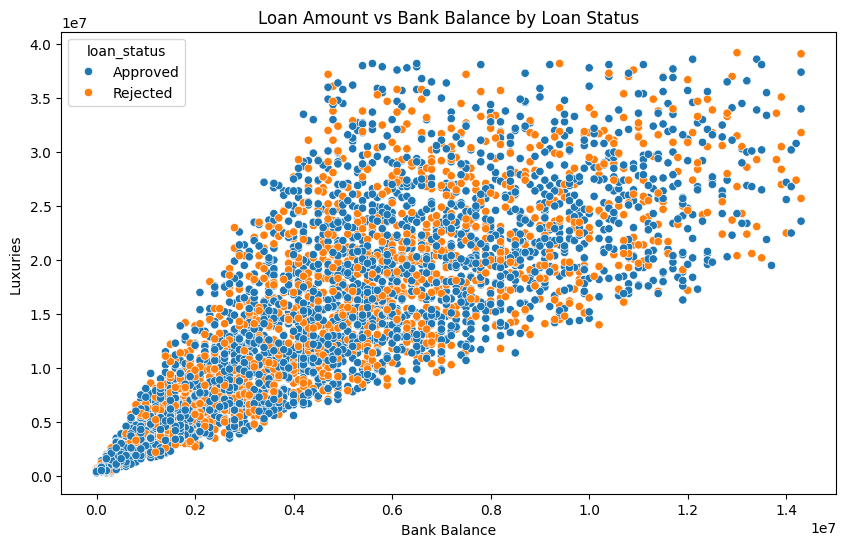

In [362]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='bank_asset_value', y='luxury_assets_value' , hue='loan_status')
plt.xlabel('Bank Balance')
plt.ylabel('Luxuries ')
plt.title('Loan Amount vs Bank Balance by Loan Status')
plt.show()

Applicants with more balance in their accounts tend to buy high value luxury items

In [363]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17050000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


<Figure size 1000x1500 with 0 Axes>

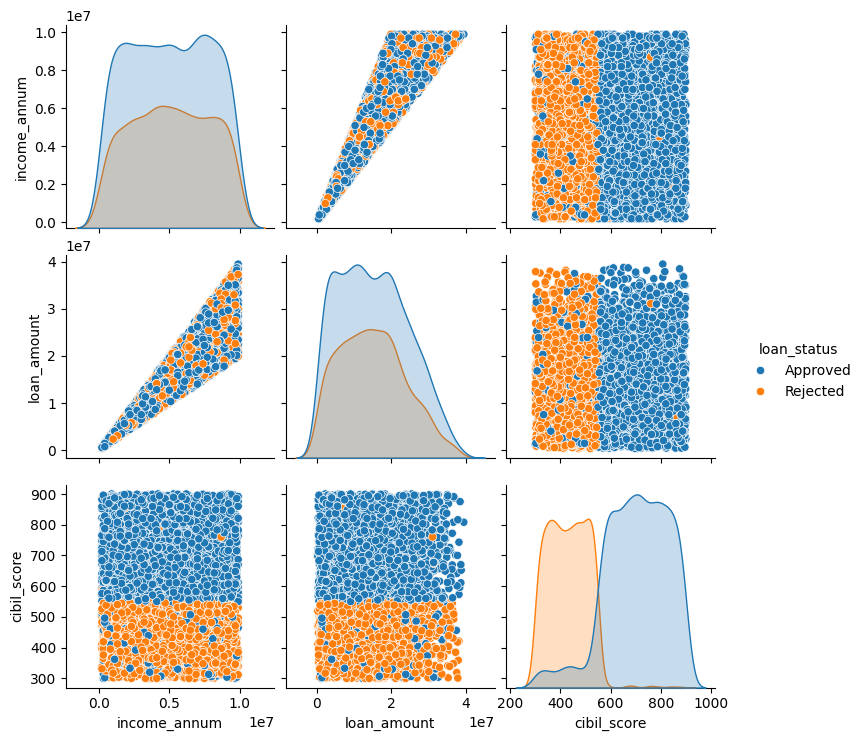

In [364]:
plt.figure(figsize=(10,15))
sns.pairplot(df[['income_annum','loan_amount','cibil_score','loan_status']], hue='loan_status')
plt.show()

In [365]:
# range of cibil score
print("CIBIL Score Range:")
print(f"Minimum: {df['cibil_score'].min()}")
print(f"Maximum: {df['cibil_score'].max()}")


CIBIL Score Range:
Minimum: 300
Maximum: 900


Text(0.5, 1.0, 'CIBIL Score by Loan Status')

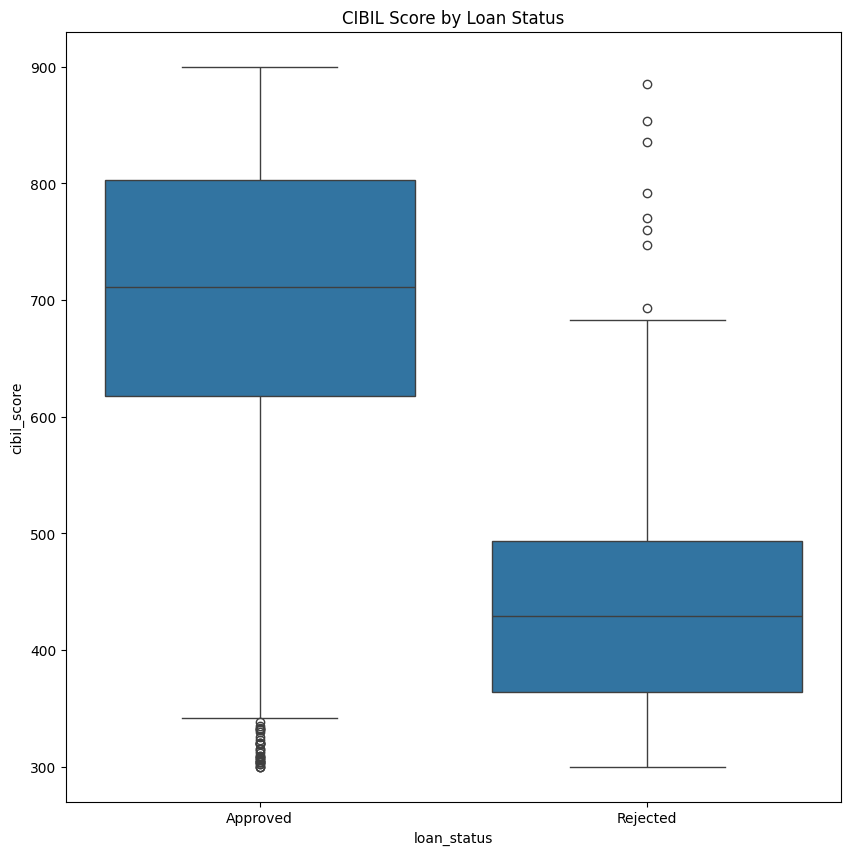

In [366]:
plt.figure(figsize=(10,10))
sns.boxplot(x='loan_status', y='cibil_score', data=df)
plt.title('CIBIL Score by Loan Status')

CIBIL Score range:
count    4269.000000
mean      599.936051
std       172.430401
min       300.000000
25%       453.000000
50%       600.000000
75%       748.000000
max       900.000000
Name: cibil_score, dtype: float64

Number of high CIBIL score (>700) rejections: 7


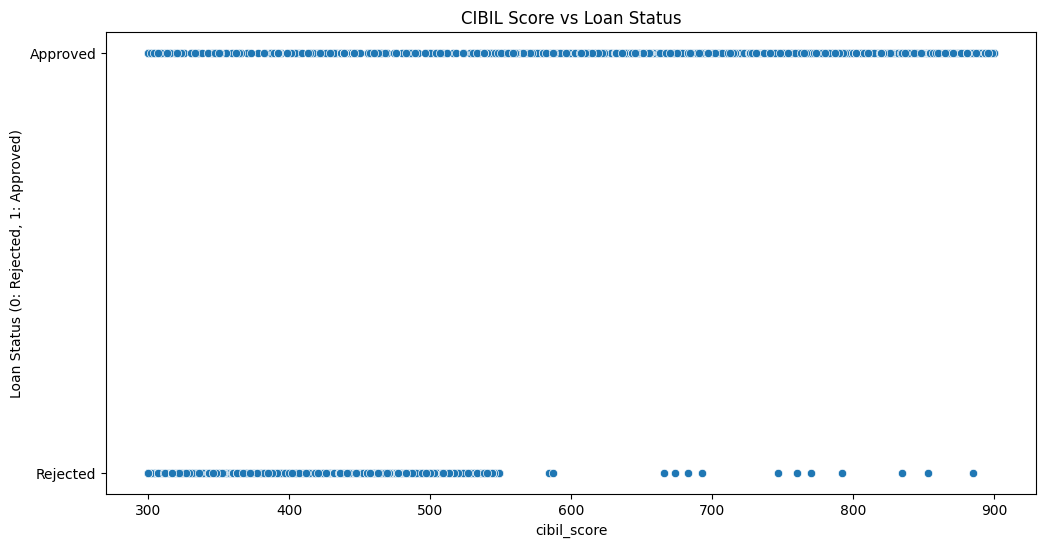

In [367]:
print("CIBIL Score range:")
print(df['cibil_score'].describe())

high_cibil_threshold = 700  # Adjust this value based on the CIBIL score range in your dataset
high_cibil_rejected = df[(df['cibil_score'] > high_cibil_threshold) & (df['loan_status'] == 'Rejected')]
print(f"\nNumber of high CIBIL score (>{high_cibil_threshold}) rejections: {len(high_cibil_rejected)}");

plt.figure(figsize=(12, 6))
sns.scatterplot(x='cibil_score', y='loan_status', data=df)
plt.title('CIBIL Score vs Loan Status')
plt.ylabel('Loan Status (0: Rejected, 1: Approved)')
plt.show();

There are about 7 Applicants who have a higher cibil_score but got rejected"

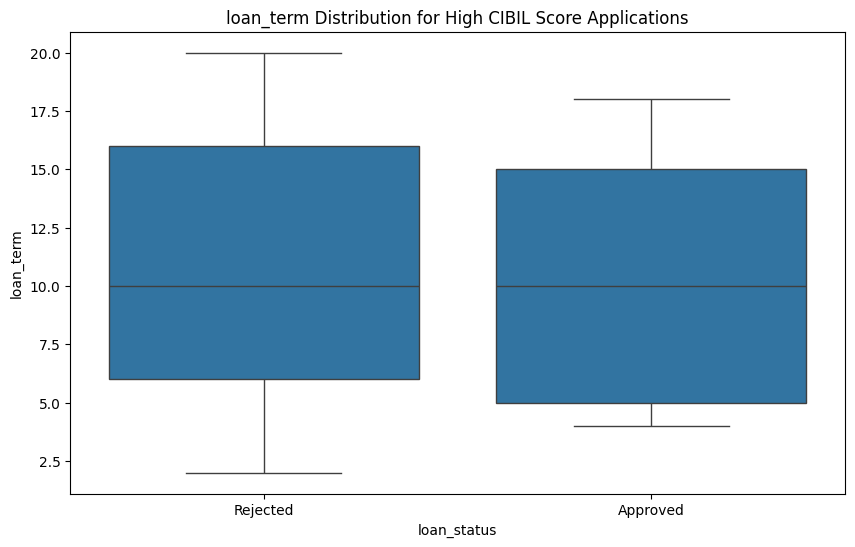

In [368]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='loan_term', data=df[df['cibil_score'] > high_cibil_threshold])
plt.title(f'{'loan_term'} Distribution for High CIBIL Score Applications')
plt.xticks([0, 1], ['Rejected', 'Approved'])
plt.show()

modeling

In [369]:

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import roc_curve

In [370]:
columns_to_drop = ["loan_id"]
df = df.drop(columns=columns_to_drop)
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17050000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [371]:
x = df.drop('loan_status', axis=1)
y = df['loan_status'].map({'Rejected': 0, 'Approved': 1})
x = pd.get_dummies(x, drop_first=True)


In [372]:
xtrain, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [373]:
sc = StandardScaler()
x_train_scaled = sc.fit_transform(xtrain)
x_test_scaled = sc.transform(x_test)

In [374]:
# make elbow methood


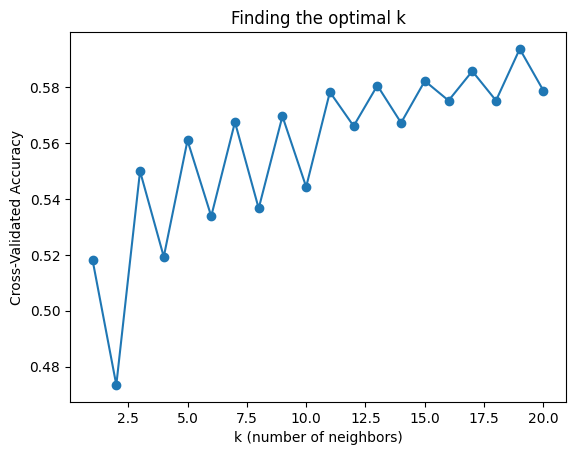

In [375]:
k_range = range(1, 21)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(knn, x, y, cv=5, scoring='accuracy')
    scores.append(cv_scores.mean())

plt.plot(k_range, scores, marker='o')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Finding the optimal k')
plt.show()

In [376]:
knn = KNeighborsClassifier(n_neighbors=16)
knn.fit(x_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",16
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [377]:
y_pred = knn.predict(x_test_scaled)

In [378]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"ROC AUC Score: {roc}")


Accuracy: 0.9016393442622951
Precision: 0.9329501915708812
Recall: 0.9085820895522388
ROC AUC Score: 0.8992595982352389


In [379]:
cv_scores = cross_val_score(knn, x_train_scaled, y_train, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean():.4f}")

Cross-validation scores: [0.88726208 0.89751098 0.91508053 0.91800878 0.92093704]
Mean CV score: 0.9078


In [380]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, criterion='gini')
rf.fit(x_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [381]:
y_pred_2 = rf.predict(x_test_scaled)
accuracy_2 = accuracy_score(y_test, y_pred_2)
precision_2 = precision_score(y_test, y_pred_2) 
recall_2 = recall_score(y_test, y_pred_2)
roc_2 = roc_auc_score(y_test, y_pred_2)

print(f"Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_2}")        
print(f"Precision: {precision_2}")
print(f"Recall: {recall_2}")
print(f"ROC AUC Score: {roc_2}")



Random Forest Classifier Performance:
Accuracy: 0.977751756440281
Precision: 0.977818853974122
Recall: 0.9869402985074627
ROC AUC Score: 0.9746022247254296


In [382]:
cv_scores_rf = cross_val_score(rf, x_train_scaled, y_train, cv=5)
print(f"Random Forest Cross-validation scores: {cv_scores_rf}")
mean_cv_rf = cv_scores_rf.mean()
print(f"Mean CV score for Random Forest: {mean_cv_rf:.4f}")

Random Forest Cross-validation scores: [0.97803807 0.97364568 0.97657394 0.97657394 0.97803807]
Mean CV score for Random Forest: 0.9766


In [383]:
log = LogisticRegression(random_state=42)
log.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [384]:
y_pred_3 = log.predict(x_test_scaled)
accuracy_3 = accuracy_score(y_test, y_pred_3)   
precision_3 = precision_score(y_test, y_pred_3)
recall_3 = recall_score(y_test, y_pred_3)
roc_3 = roc_auc_score(y_test, y_pred_3)
print(f"Logistic Regression Performance:")
print(f"Accuracy: {accuracy_3}")
print(f"Precision: {precision_3}")
print(f"Recall: {recall_3}")
print(f"ROC AUC Score: {roc_3}")


Logistic Regression Performance:
Accuracy: 0.905152224824356
Precision: 0.9205175600739371
Recall: 0.9291044776119403
ROC AUC Score: 0.8969421759128884


In [385]:
cv_scores_log = cross_val_score(log, x_train_scaled, y_train, cv=5)
print(f"Logistic Regression Cross-validation scores: {cv_scores_log}")
mean_cv_log = cv_scores_log.mean()
print(f"Mean CV score for Logistic Regression: {mean_cv_log:.4f}")

Logistic Regression Cross-validation scores: [0.90629575 0.91068814 0.93118594 0.91508053 0.92972182]
Mean CV score for Logistic Regression: 0.9186


In [386]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = log.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_3))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred_3))

Test Accuracy: 0.905152224824356
Confusion Matrix:
 [[  0 318]
 [  0 536]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87       318
           1       0.92      0.93      0.92       536

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854



c:\Users\omare\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
